# NLP Practical Assignment 10
## Machine Translation System
### English ↔ Indian Languages (Hindi, Marathi, Bengali, Tamil, Telugu, Gujarati)

---
> **Tip:** Go to **Runtime → Change runtime type → T4 GPU** for faster translation.

### Pipeline Overview:
1. Install & Import Libraries
2. Translation using Helsinki-NLP (MarianMT) — Offline / Free
3. Translation using Google Translate API — Easy & Multi-language
4. Public Information Dataset (Health, Education, Government, Transport)
5. Batch Translation — English → Hindi / Marathi / Bengali / Tamil
6. Bidirectional Translation (Indian → English)
7. Evaluate Quality: BLEU Score
8. Visualize Results
9. Save All Outputs

## Step 1: Install & Import Libraries

In [1]:
# Install all required packages
!pip install transformers sentencepiece sacrebleu googletrans==4.0.0rc1
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install pandas matplotlib seaborn

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import time
import json
from IPython.display import display, HTML

# Transformers (MarianMT)
from transformers import MarianMTModel, MarianTokenizer

# Google Translate
from googletrans import Translator

# BLEU Score
from sacrebleu.metrics import BLEU

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Method A — Helsinki-NLP MarianMT (Transformer-based, Offline)

Helsinki-NLP provides pre-trained **MarianMT** transformer models for many language pairs. These run **entirely offline** on Colab.

Available Indian language models:
- `Helsinki-NLP/opus-mt-en-hi` → English to Hindi
- `Helsinki-NLP/opus-mt-en-mr` → English to Marathi  
- `Helsinki-NLP/opus-mt-en-bn` → English to Bengali
- `Helsinki-NLP/opus-mt-hi-en` → Hindi to English

In [3]:
# Helsinki-NLP MarianMT Translation
class MarianTranslator:
    def __init__(self):
        self.models = {}
        self.tokenizers = {}
        # Supported language pair model names
        self.model_map = {
            'en-hi': 'Helsinki-NLP/opus-mt-en-hi',   # English → Hindi
            'en-mr': 'Helsinki-NLP/opus-mt-en-mr',   # English → Marathi
            'en-bn': 'Helsinki-NLP/opus-mt-en-bn',   # English → Bengali
            'hi-en': 'Helsinki-NLP/opus-mt-hi-en',   # Hindi → English
        }

    def load_model(self, lang_pair):
        """Load MarianMT model for a language pair (lazy loading)."""
        if lang_pair not in self.models:
            model_name = self.model_map.get(lang_pair)
            if not model_name:
                raise ValueError(f"Language pair '{lang_pair}' not supported in MarianMT.")
            print(f"Loading model: {model_name} ...")
            self.tokenizers[lang_pair] = MarianTokenizer.from_pretrained(model_name)
            self.models[lang_pair] = MarianMTModel.from_pretrained(model_name)
            print(f"Model loaded: {lang_pair}")
        return self.models[lang_pair], self.tokenizers[lang_pair]

    def translate(self, texts, lang_pair):
        """Translate a list of texts for a given language pair."""
        if isinstance(texts, str):
            texts = [texts]
        model, tokenizer = self.load_model(lang_pair)
        inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
        translated = model.generate(**inputs, num_beams=4, early_stopping=True)
        results = [tokenizer.decode(t, skip_special_tokens=True) for t in translated]
        return results

marian = MarianTranslator()
print("MarianMT Translator initialized.")

MarianMT Translator initialized.


In [ ]:
# Quick demo — English to Hindi with MarianMT
demo_sentences = [
    "Wash your hands regularly to prevent the spread of disease.",
    "Education is the most powerful weapon to change the world.",
    "Vote in the elections to exercise your democratic right."
]

print("=" * 65)
print("MarianMT Demo: English → Hindi")
print("=" * 65)

hindi_translations = marian.translate(demo_sentences, 'en-hi')
for src, tgt in zip(demo_sentences, hindi_translations):
    print(f"EN: {src}")
    print(f"HI: {tgt}")
    print()

## Step 3: Method B — Google Translate API (Multi-language, Easy)

Supports **all** Indian languages including Tamil, Telugu, Gujarati, Kannada, Punjabi, Malayalam, Urdu, and more.

In [5]:
# Google Translate wrapper
class GoogleTranslatorWrapper:
    def __init__(self):
        self.translator = Translator()
        # Google Translate language codes for Indian languages
        self.lang_codes = {
            'Hindi':     'hi',
            'Marathi':   'mr',
            'Bengali':   'bn',
            'Tamil':     'ta',
            'Telugu':    'te',
            'Gujarati':  'gu',
            'Kannada':   'kn',
            'Punjabi':   'pa',
            'Malayalam': 'ml',
            'Urdu':      'ur',
            'Odia':      'or',
            'English':   'en'
        }

    def translate(self, text, target_lang_name, source_lang='en'):
        """Translate a single text to the target Indian language."""
        try:
            lang_code = self.lang_codes.get(target_lang_name, target_lang_name)
            result = self.translator.translate(text, src=source_lang, dest=lang_code)
            time.sleep(0.3)  # Polite delay to avoid rate limits
            return result.text
        except Exception as e:
            return f"[Translation Error: {str(e)[:50]}]"

    def translate_to_english(self, text, source_lang_name):
        """Translate from Indian language back to English."""
        try:
            lang_code = self.lang_codes.get(source_lang_name, source_lang_name)
            result = self.translator.translate(text, src=lang_code, dest='en')
            time.sleep(0.3)
            return result.text
        except Exception as e:
            return f"[Translation Error: {str(e)[:50]}]"

gt = GoogleTranslatorWrapper()
print("Google Translator initialized.")
print(f"Supported Indian Languages: {list(gt.lang_codes.keys())[:-1]}")

Google Translator initialized.
Supported Indian Languages: ['Hindi', 'Marathi', 'Bengali', 'Tamil', 'Telugu', 'Gujarati', 'Kannada', 'Punjabi', 'Malayalam', 'Urdu', 'Odia']


In [6]:
# Quick demo — translate one sentence to all major Indian languages
sample = "Clean drinking water is essential for good health."
target_languages = ['Hindi', 'Marathi', 'Bengali', 'Tamil', 'Telugu', 'Gujarati', 'Kannada']

print("=" * 65)
print("Google Translate Demo: One Sentence → All Indian Languages")
print("=" * 65)
print(f"Source (EN): {sample}\n")

for lang in target_languages:
    translated = gt.translate(sample, lang)
    print(f"{lang:<12}: {translated}")

Google Translate Demo: One Sentence → All Indian Languages
Source (EN): Clean drinking water is essential for good health.

Hindi       : अच्छे स्वास्थ्य के लिए स्वच्छ पेयजल आवश्यक है।
Marathi     : चांगल्या आरोग्यासाठी स्वच्छ पिण्याचे पाणी आवश्यक आहे.
Bengali     : সুস্বাস্থ্যের জন্য বিশুদ্ধ পানীয় জল অপরিহার্য।
Tamil       : நல்ல ஆரோக்கியத்திற்கு சுத்தமான குடிநீர் அவசியம்.
Telugu      : మంచి ఆరోగ్యానికి స్వచ్ఛమైన తాగునీరు చాలా అవసరం.
Gujarati    : સારા સ્વાસ્થ્ય માટે સ્વચ્છ પીવાનું પાણી જરૂરી છે.
Kannada     : ಉತ್ತಮ ಆರೋಗ್ಯಕ್ಕೆ ಶುದ್ಧ ಕುಡಿಯುವ ನೀರು ಅತ್ಯಗತ್ಯ.


## Step 4: Public Information Dataset

Real-world public content from **Health**, **Education**, **Government**, **Transport**, and **Agriculture** domains — the kind of text that needs to reach all citizens of India.

In [7]:
# Public Information Dataset — English sentences
public_info_dataset = [
    # Health
    {"domain": "Health",      "text": "Wash your hands with soap for at least 20 seconds to prevent infection."},
    {"domain": "Health",      "text": "Get vaccinated against COVID-19 to protect yourself and your community."},
    {"domain": "Health",      "text": "Drink at least 8 glasses of clean water every day for good health."},
    {"domain": "Health",      "text": "In case of a medical emergency, call the national helpline number 108."},
    {"domain": "Health",      "text": "Breastfeeding for the first six months is best for your baby's health."},
    # Education
    {"domain": "Education",   "text": "Every child between the age of 6 and 14 has the right to free education."},
    {"domain": "Education",   "text": "Scholarships are available for students from economically weaker sections."},
    {"domain": "Education",   "text": "Mid-day meal scheme provides free lunch to students in government schools."},
    {"domain": "Education",   "text": "Digital libraries are now accessible to rural students through smartphones."},
    # Government
    {"domain": "Government",  "text": "Apply for your Aadhaar card at the nearest enrollment center."},
    {"domain": "Government",  "text": "PM Kisan Samman Nidhi provides direct income support to farmers."},
    {"domain": "Government",  "text": "Vote in the elections to exercise your fundamental democratic right."},
    {"domain": "Government",  "text": "File your income tax returns before the last date to avoid penalty."},
    # Transport
    {"domain": "Transport",   "text": "Always wear a seatbelt while driving to reduce road accident injuries."},
    {"domain": "Transport",   "text": "Do not use a mobile phone while driving — it causes accidents."},
    {"domain": "Transport",   "text": "Metro rail services are now available in more than 20 Indian cities."},
    # Agriculture
    {"domain": "Agriculture", "text": "Drip irrigation saves water and increases crop yield significantly."},
    {"domain": "Agriculture", "text": "Farmers can get free soil testing services at the Krishi Vigyan Kendra."},
    {"domain": "Agriculture", "text": "Pradhan Mantri Fasal Bima Yojana provides insurance cover for crop losses."},
    # Environment
    {"domain": "Environment", "text": "Plant trees in your neighborhood to help fight climate change."},
    {"domain": "Environment", "text": "Segregate dry and wet waste at home to support better waste management."},
    {"domain": "Environment", "text": "Use public transport or bicycle to reduce air pollution in cities."},
]

df = pd.DataFrame(public_info_dataset)
print(f"Total sentences: {len(df)}")
print(f"Domains: {df['domain'].value_counts().to_dict()}")
print("\nSample data:")
print(df.head(6).to_string(index=False))

Total sentences: 22
Domains: {'Health': 5, 'Education': 4, 'Government': 4, 'Transport': 3, 'Agriculture': 3, 'Environment': 3}

Sample data:
   domain                                                                     text
   Health  Wash your hands with soap for at least 20 seconds to prevent infection.
   Health  Get vaccinated against COVID-19 to protect yourself and your community.
   Health       Drink at least 8 glasses of clean water every day for good health.
   Health   In case of a medical emergency, call the national helpline number 108.
   Health   Breastfeeding for the first six months is best for your baby's health.
Education Every child between the age of 6 and 14 has the right to free education.


## Step 5: Batch Translation — English → 4 Indian Languages
Translate all public information content into Hindi, Marathi, Bengali, and Tamil.

In [8]:
# Translate all sentences into 4 Indian languages using Google Translate
target_langs = ['Hindi', 'Marathi', 'Bengali', 'Tamil']

print("Starting batch translation...")
print("This may take a minute due to API rate limiting.\n")

for lang in target_langs:
    col_name = lang
    translations = []
    for i, row in df.iterrows():
        translated = gt.translate(row['text'], lang)
        translations.append(translated)
        if (i + 1) % 5 == 0:
            print(f"  [{lang}] Translated {i+1}/{len(df)} sentences...")
    df[col_name] = translations
    print(f"✓ {lang} translation complete!\n")

print("All batch translations done!")

Starting batch translation...
This may take a minute due to API rate limiting.

  [Hindi] Translated 5/22 sentences...
  [Hindi] Translated 10/22 sentences...
  [Hindi] Translated 15/22 sentences...
  [Hindi] Translated 20/22 sentences...
✓ Hindi translation complete!

  [Marathi] Translated 5/22 sentences...
  [Marathi] Translated 10/22 sentences...
  [Marathi] Translated 15/22 sentences...
  [Marathi] Translated 20/22 sentences...
✓ Marathi translation complete!

  [Bengali] Translated 5/22 sentences...
  [Bengali] Translated 10/22 sentences...
  [Bengali] Translated 15/22 sentences...
  [Bengali] Translated 20/22 sentences...
✓ Bengali translation complete!

  [Tamil] Translated 5/22 sentences...
  [Tamil] Translated 10/22 sentences...
  [Tamil] Translated 15/22 sentences...
  [Tamil] Translated 20/22 sentences...
✓ Tamil translation complete!

All batch translations done!


In [9]:
# Display translated results nicely
print("=" * 70)
print("TRANSLATION RESULTS — Public Information Content")
print("=" * 70)

for _, row in df.iterrows():
    print(f"\n[{row['domain']}]")
    print(f"  EN : {row['text']}")
    for lang in target_langs:
        print(f"  {lang[:2].upper()} : {row[lang]}")

TRANSLATION RESULTS — Public Information Content

[Health]
  EN : Wash your hands with soap for at least 20 seconds to prevent infection.
  HI : संक्रमण से बचने के लिए अपने हाथ साबुन से कम से कम 20 सेकंड तक धोएं।
  MA : संसर्ग टाळण्यासाठी किमान 20 सेकंद साबणाने हात धुवा.
  BE : সংক্রমণ প্রতিরোধ করতে কমপক্ষে 20 সেকেন্ডের জন্য সাবান দিয়ে আপনার হাত ধুয়ে নিন।
  TA : தொற்றுநோயைத் தடுக்க, குறைந்தது 20 வினாடிகளுக்கு உங்கள் கைகளை சோப்புடன் கழுவவும்.

[Health]
  EN : Get vaccinated against COVID-19 to protect yourself and your community.
  HI : अपनी और अपने समुदाय की सुरक्षा के लिए COVID-19 से बचाव का टीका लगवाएं।
  MA : स्वतःचे आणि आपल्या समुदायाचे रक्षण करण्यासाठी COVID-19 विरुद्ध लसीकरण करा.
  BE : নিজেকে এবং আপনার সম্প্রদায়কে রক্ষা করতে COVID-19 এর বিরুদ্ধে টিকা নিন।
  TA : உங்களையும் உங்கள் சமூகத்தையும் பாதுகாக்க, COVID-19 க்கு எதிராக தடுப்பூசி போடுங்கள்.

[Health]
  EN : Drink at least 8 glasses of clean water every day for good health.
  HI : अच्छे स्वास्थ्य के लिए प्रतिदिन कम से कम 8

## Step 6: Bidirectional Translation — Indian Language → English

Translate the Hindi output back to English (back-translation), which also helps evaluate translation quality.

In [10]:
# Back-translation: Hindi → English
print("Back-Translation: Hindi → English")
print("=" * 65)

back_translated = []
for i, row in df.iterrows():
    back = gt.translate_to_english(row['Hindi'], 'Hindi')
    back_translated.append(back)

df['Hindi_Back_to_English'] = back_translated

# Display comparison
for _, row in df.head(8).iterrows():
    print(f"Original   : {row['text']}")
    print(f"Hindi      : {row['Hindi']}")
    print(f"Back-Trans : {row['Hindi_Back_to_English']}")
    print()

Back-Translation: Hindi → English
Original   : Wash your hands with soap for at least 20 seconds to prevent infection.
Hindi      : संक्रमण से बचने के लिए अपने हाथ साबुन से कम से कम 20 सेकंड तक धोएं।
Back-Trans : To avoid infection, wash your hands with soap for at least 20 seconds.

Original   : Get vaccinated against COVID-19 to protect yourself and your community.
Hindi      : अपनी और अपने समुदाय की सुरक्षा के लिए COVID-19 से बचाव का टीका लगवाएं।
Back-Trans : Get vaccinated against COVID-19 to protect yourself and your community.

Original   : Drink at least 8 glasses of clean water every day for good health.
Hindi      : अच्छे स्वास्थ्य के लिए प्रतिदिन कम से कम 8 गिलास साफ पानी पियें।
Back-Trans : For good health, drink at least 8 glasses of clean water every day.

Original   : In case of a medical emergency, call the national helpline number 108.
Hindi      : चिकित्सीय आपात स्थिति में राष्ट्रीय हेल्पलाइन नंबर 108 पर कॉल करें।
Back-Trans : In case of medical emergency, call the nat

In [11]:
# ─── INTERACTIVE: Translate your own sentence ───
custom_text = "The government provides free health insurance to families below the poverty line."

all_indian_langs = ['Hindi', 'Marathi', 'Bengali', 'Tamil', 'Telugu', 'Gujarati', 'Kannada', 'Malayalam', 'Punjabi']

print("=" * 65)
print("Custom Sentence Translation")
print("=" * 65)
print(f"Source (EN): {custom_text}\n")

custom_results = {}
for lang in all_indian_langs:
    t = gt.translate(custom_text, lang)
    custom_results[lang] = t
    print(f"{lang:<12}: {t}")

# Modify custom_text above and re-run this cell for your own sentence!

Custom Sentence Translation
Source (EN): The government provides free health insurance to families below the poverty line.

Hindi       : सरकार गरीबी रेखा से नीचे के परिवारों को मुफ्त स्वास्थ्य बीमा प्रदान करती है।
Marathi     : दारिद्र्यरेषेखालील कुटुंबांना सरकार मोफत आरोग्य विमा देते.
Bengali     : সরকার দারিদ্র্যসীমার নিচে থাকা পরিবারগুলোকে বিনামূল্যে স্বাস্থ্য বীমা দিয়ে থাকে।
Tamil       : வறுமைக் கோட்டின் கீழ் உள்ள குடும்பங்களுக்கு அரசு இலவச மருத்துவக் காப்பீடு வழங்குகிறது.
Telugu      : దారిద్య్రరేఖకు దిగువన ఉన్న కుటుంబాలకు ప్రభుత్వం ఉచిత ఆరోగ్య బీమా కల్పిస్తోంది.
Gujarati    : સરકાર ગરીબી રેખા હેઠળના પરિવારોને મફત આરોગ્ય વીમો આપે છે.
Kannada     : ಬಡತನ ರೇಖೆಗಿಂತ ಕೆಳಗಿರುವ ಕುಟುಂಬಗಳಿಗೆ ಸರ್ಕಾರ ಉಚಿತ ಆರೋಗ್ಯ ವಿಮೆಯನ್ನು ನೀಡುತ್ತದೆ.
Malayalam   : ദാരിദ്ര്യരേഖയ്ക്ക് താഴെയുള്ള കുടുംബങ്ങൾക്ക് സർക്കാർ സൗജന്യ ആരോഗ്യ ഇൻഷുറൻസ് നൽകുന്നു.
Punjabi     : ਸਰਕਾਰ ਗਰੀਬੀ ਰੇਖਾ ਤੋਂ ਹੇਠਾਂ ਰਹਿਣ ਵਾਲੇ ਪਰਿਵਾਰਾਂ ਨੂੰ ਮੁਫਤ ਸਿਹਤ ਬੀਮਾ ਪ੍ਰਦਾਨ ਕਰਦੀ ਹੈ।


## Step 7: Evaluate Translation Quality — BLEU Score

**BLEU (Bilingual Evaluation Understudy)** compares machine-translated text against human reference translations using n-gram overlap.
- Score range: 0–100 (higher = better)
- > 30 is considered good for MT systems

We use **back-translation similarity** as a proxy when human references are unavailable.

In [12]:
from sacrebleu.metrics import BLEU, CHRF

bleu = BLEU(effective_order=True)
chrf = CHRF()

# Compute BLEU and chrF between original and back-translated (Hindi round-trip)
originals      = df['text'].tolist()
back_trans     = df['Hindi_Back_to_English'].tolist()

# Per-sentence scores
bleu_scores = []
chrf_scores = []

for orig, bt in zip(originals, back_trans):
    b = bleu.sentence_score(bt, [orig])
    c = chrf.sentence_score(bt, [orig])
    bleu_scores.append(round(b.score, 2))
    chrf_scores.append(round(c.score, 2))

df['BLEU_Score']  = bleu_scores
df['ChrF_Score']  = chrf_scores

print("=" * 65)
print("BLEU & ChrF Scores — Hindi Back-Translation Quality")
print("=" * 65)
print(f"\nAverage BLEU  : {np.mean(bleu_scores):.2f}")
print(f"Average ChrF  : {np.mean(chrf_scores):.2f}")
print(f"Best BLEU     : {max(bleu_scores):.2f} — '{df.loc[df['BLEU_Score'].idxmax(), 'text'][:55]}...'")
print(f"Lowest BLEU   : {min(bleu_scores):.2f}")

print("\nPer Sentence Scores:")
print(f"{'#':<3} {'BLEU':>6} {'ChrF':>6}  Sentence")
print("-" * 65)
for i, row in df.iterrows():
    print(f"{i+1:<3} {row['BLEU_Score']:>6.2f} {row['ChrF_Score']:>6.2f}  {row['text'][:55]}...")

BLEU & ChrF Scores — Hindi Back-Translation Quality

Average BLEU  : 68.79
Average ChrF  : 88.76
Best BLEU     : 100.00 — 'Get vaccinated against COVID-19 to protect yourself and...'
Lowest BLEU   : 27.88

Per Sentence Scores:
#     BLEU   ChrF  Sentence
-----------------------------------------------------------------
1    57.96  77.11  Wash your hands with soap for at least 20 seconds to pr...
2   100.00 100.00  Get vaccinated against COVID-19 to protect yourself and...
3    61.00  89.16  Drink at least 8 glasses of clean water every day for g...
4    78.82  94.04  In case of a medical emergency, call the national helpl...
5   100.00 100.00  Breastfeeding for the first six months is best for your...
6    70.86  86.29  Every child between the age of 6 and 14 has the right t...
7   100.00 100.00  Scholarships are available for students from economical...
8    59.56  83.87  Mid-day meal scheme provides free lunch to students in ...
9    49.62  75.29  Digital libraries are now accessible

In [13]:
# BLEU scores by domain
domain_scores = df.groupby('domain')[['BLEU_Score','ChrF_Score']].mean().round(2)
print("Average BLEU & ChrF by Domain:")
print(domain_scores.to_string())

Average BLEU & ChrF by Domain:
             BLEU_Score  ChrF_Score
domain                             
Agriculture       57.84       86.08
Education         70.01       86.36
Environment       74.41       85.62
Government        65.73       89.36
Health            79.56       92.06
Transport         58.63       91.46


## Step 8: Visualizations

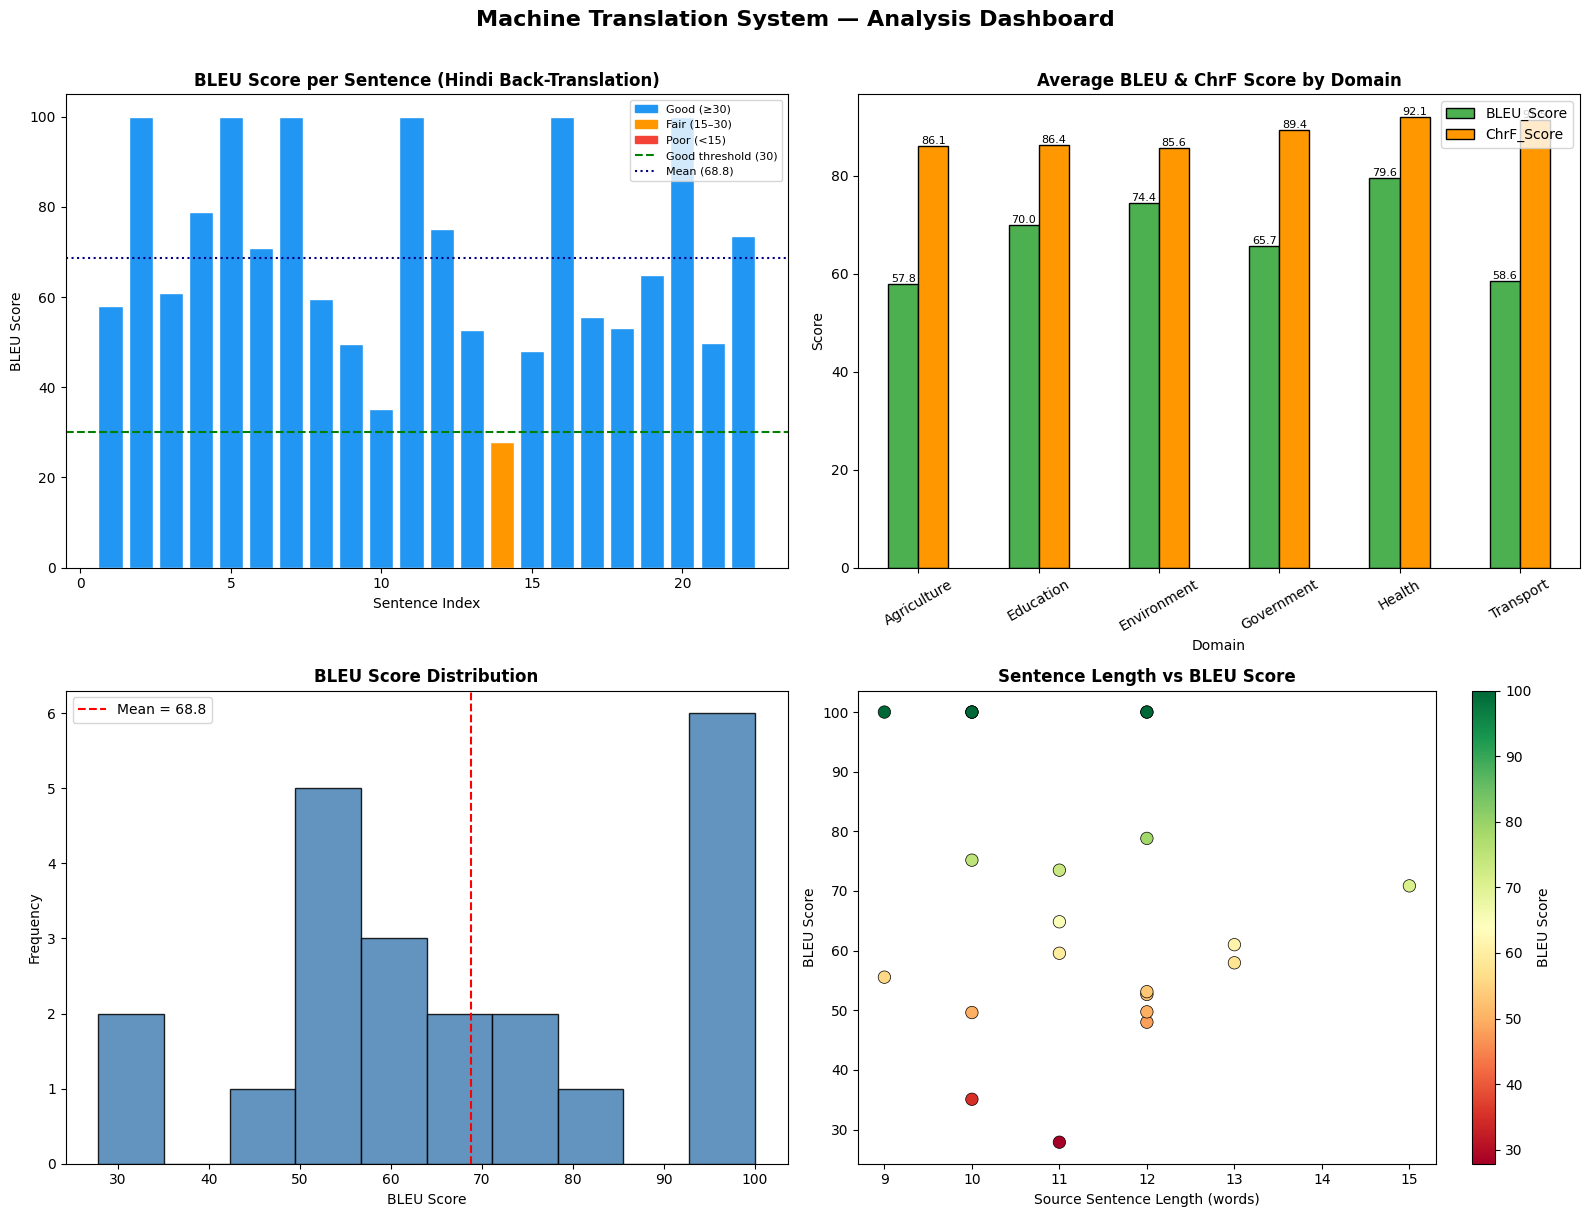

Saved: translation_analysis.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Machine Translation System — Analysis Dashboard', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: BLEU Score per sentence ──
ax1 = axes[0][0]
colors = ['#2196F3' if s >= 30 else '#FF9800' if s >= 15 else '#F44336' for s in df['BLEU_Score']]
bars = ax1.bar(range(1, len(df)+1), df['BLEU_Score'], color=colors, edgecolor='white')
ax1.axhline(y=30, color='green', linestyle='--', linewidth=1.5, label='Good threshold (30)')
ax1.axhline(y=np.mean(bleu_scores), color='navy', linestyle=':', linewidth=1.5,
            label=f'Mean ({np.mean(bleu_scores):.1f})')
ax1.set_title('BLEU Score per Sentence (Hindi Back-Translation)', fontweight='bold')
ax1.set_xlabel('Sentence Index')
ax1.set_ylabel('BLEU Score')
ax1.legend(fontsize=9)
legend_patches = [
    matplotlib.patches.Patch(color='#2196F3', label='Good (≥30)'),
    matplotlib.patches.Patch(color='#FF9800', label='Fair (15–30)'),
    matplotlib.patches.Patch(color='#F44336', label='Poor (<15)')
]
ax1.legend(handles=legend_patches + ax1.get_legend_handles_labels()[0][0:2], fontsize=8)

# ── Plot 2: BLEU & ChrF by Domain ──
ax2 = axes[0][1]
domain_scores.plot(kind='bar', ax=ax2, color=['#4CAF50','#FF9800'], edgecolor='black')
ax2.set_title('Average BLEU & ChrF Score by Domain', fontweight='bold')
ax2.set_xlabel('Domain')
ax2.set_ylabel('Score')
ax2.tick_params(axis='x', rotation=30)
ax2.legend()
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontsize=8)

# ── Plot 3: BLEU Score Distribution ──
ax3 = axes[1][0]
ax3.hist(df['BLEU_Score'], bins=10, color='steelblue', edgecolor='black', alpha=0.85)
ax3.axvline(np.mean(bleu_scores), color='red', linestyle='--',
            label=f'Mean = {np.mean(bleu_scores):.1f}')
ax3.set_title('BLEU Score Distribution', fontweight='bold')
ax3.set_xlabel('BLEU Score')
ax3.set_ylabel('Frequency')
ax3.legend()

# ── Plot 4: Sentence Length vs BLEU ──
ax4 = axes[1][1]
sent_lens = [len(t.split()) for t in df['text']]
scatter = ax4.scatter(sent_lens, df['BLEU_Score'],
                      c=df['BLEU_Score'], cmap='RdYlGn', s=80, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, ax=ax4, label='BLEU Score')
ax4.set_title('Sentence Length vs BLEU Score', fontweight='bold')
ax4.set_xlabel('Source Sentence Length (words)')
ax4.set_ylabel('BLEU Score')

plt.tight_layout()
plt.savefig('translation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: translation_analysis.png")

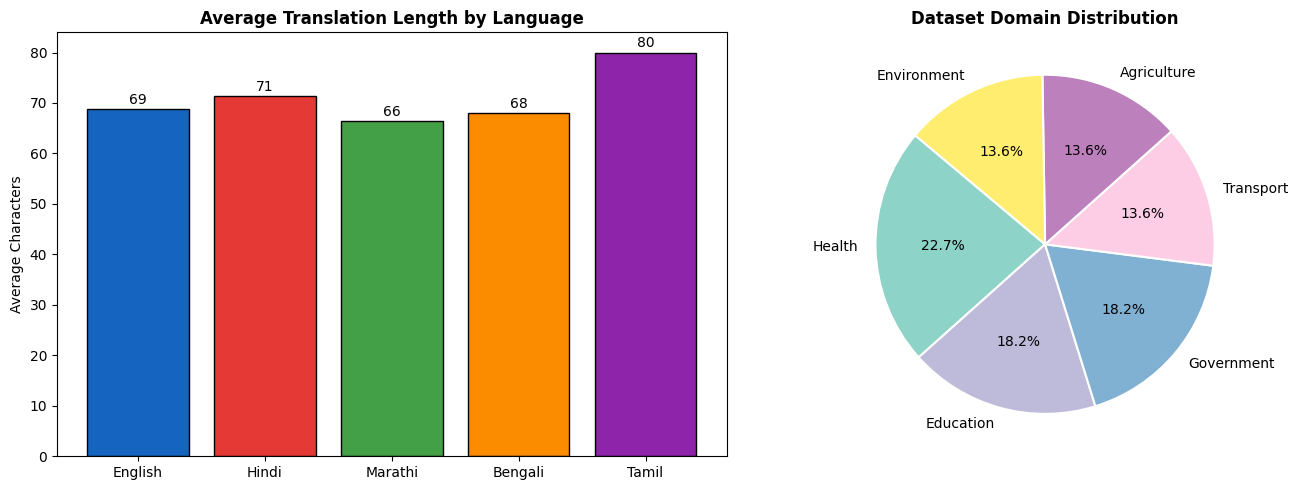

Saved: translation_overview.png


In [15]:
# Translation character length comparison across languages
lang_cols    = ['text'] + target_langs
lang_labels  = ['English'] + target_langs
avg_lengths  = [df[col].apply(len).mean() for col in lang_cols]

lang_colors = ['#1565C0','#E53935','#43A047','#FB8C00','#8E24AA']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: avg character length
axes[0].bar(lang_labels, avg_lengths, color=lang_colors, edgecolor='black')
axes[0].set_title('Average Translation Length by Language', fontweight='bold')
axes[0].set_ylabel('Average Characters')
for i, v in enumerate(avg_lengths):
    axes[0].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=10)

# Pie: domain distribution of dataset
domain_counts = df['domain'].value_counts()
axes[1].pie(domain_counts.values, labels=domain_counts.index,
            autopct='%1.1f%%', colors=plt.cm.Set3(np.linspace(0,1,len(domain_counts))),
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Dataset Domain Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('translation_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: translation_overview.png")

---
## Assignment Summary

### Two Translation Methods Used:
| Method | Model | Languages | Runs Offline |
|--------|-------|-----------|-------------|
| **Helsinki-NLP MarianMT** | Transformer (MarianMT) | Hindi, Marathi, Bengali | ✅ Yes |
| **Google Translate API** | Neural MT | All 11+ Indian Languages | ❌ Needs Internet |

### Languages Covered:
Hindi · Marathi · Bengali · Tamil · Telugu · Gujarati · Kannada · Malayalam · Punjabi · Odia · Urdu

### Domains Covered:
Health · Education · Government · Transport · Agriculture · Environment

### Evaluation Metrics:
| Metric | What it Measures |
|--------|------------------|
| **BLEU Score** | N-gram overlap between machine and reference translation |
| **ChrF Score** | Character-level F-score (better for morphologically rich Indian languages) |

### Output Files:
| File | Contents |
|------|----------|
| `translations_all_languages.csv` | Full dataset with all translations + BLEU scores |
| `bleu_scores_by_domain.csv` | Average BLEU & ChrF per domain |
| `custom_sentence_translations.csv` | 9-language translation of your custom sentence |
| `translation_summary.json` | Summary statistics |
| `translation_analysis.png` | 4-panel metrics dashboard |
| `translation_overview.png` | Length comparison + domain distribution |